In [72]:
%load_ext autoreload
%autoreload 2

from tasks.addition.addition import addition_task, sample_addition_problem
from tasks.addition.triple_add_12_3 import triple_add_task, sample_triple_add_problem
import random

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [73]:
# Load LM
from neural.pipeline import LMPipeline
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "allenai/OLMo-2-0425-1B" # "Qwen/Qwen2.5-0.5B"
pipeline = LMPipeline(model_name, max_new_tokens=1, device=device, dtype=torch.bfloat16, max_length=32)
pipeline.tokenizer.padding_side = "left"

def checker(neural_output, causal_output):
    return causal_output in neural_output["string"] or neural_output["string"] in causal_output

print("DEVICE:", pipeline.model.device)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

DEVICE: cuda:0


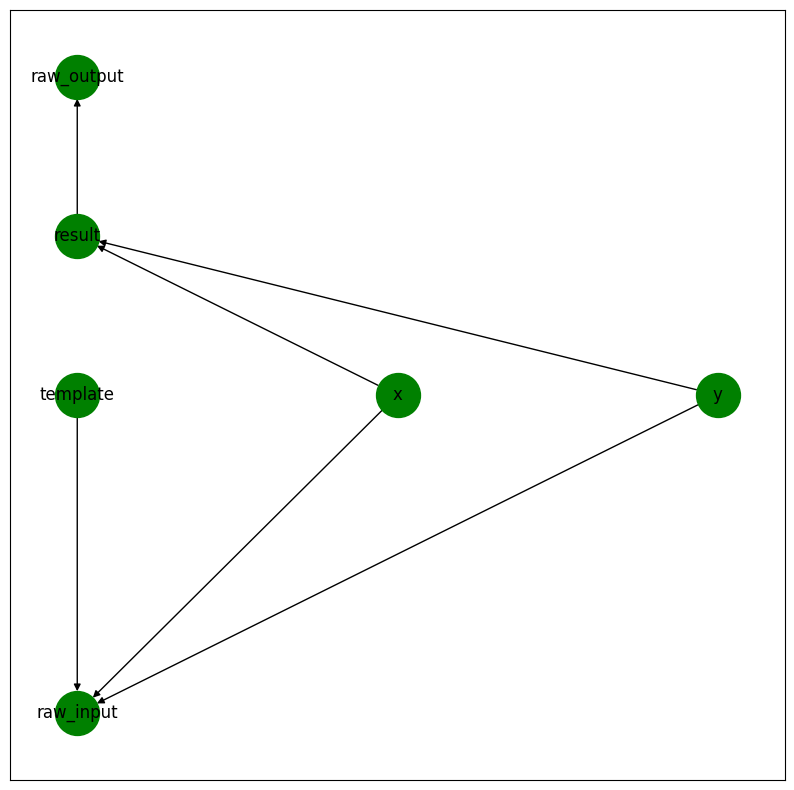

In [74]:
# Define causal model
causal_model = addition_task.causal_models["two_number_addition"]
causal_model.print_structure()

In [75]:
# Confirm interchange intervention works as expected
example = sample_addition_problem()
full_setting = causal_model.run_forward(example)
new_example = sample_addition_problem()
new_full_setting = causal_model.run_forward(new_example)

x0, y0 = example["x"], example["y"]
print(f"Original is {x0} + {y0}  =  {x0+y0}")

x1, y1 = new_example["x"], new_example["y"]
print(f"New one  is {x1} + {y1}  =  {x1+y1}")
print()
print(f"Intervention should be {x1} + {y0}  =  {x1+y0}")

intervened_full_setting = causal_model.run_interchange(example, {"x": new_example})
intervened_full_setting

Original is 12 + 5  =  17
New one  is 5 + 13  =  18

Intervention should be 5 + 5  =  10


defaultdict(None,
            {'template': '<|endoftext|>, Yes, <x> + <y> = ',
             'x': 5,
             'y': 5,
             'result': 10,
             'raw_input': '<|endoftext|>, Yes, 12 + 5 = ',
             'raw_output': '10'})

In [76]:
# # Compare LM outputs for single pair intervention
# # Takes about 35 seconds

# # Import the tracing experiment
# from experiments.LM_experiments.residual_stream_experiment import SameLengthResidualStreamTracing

# original = sample_addition_problem()
# counterfactual = sample_addition_problem()

# x0, y0 = original["x"], original["y"]
# neural_output = pipeline.generate(original["raw_input"])["string"]
# print("Original:")
# print(f"Causal output is {x0} + {y0}  =  {x0+y0}")
# print(f"Neural output is {neural_output}")

# x1, y1 = counterfactual["x"], counterfactual["y"]
# neural_output = pipeline.generate(counterfactual["raw_input"])["string"]
# print("\nCounterfactual:")
# print(f"Causal output is {x1} + {y1}  =  {x1+y1}")
# print(f"Neural output is {neural_output}")

# # Run the tracing experiment
# print("\n" + "="*50)
# print("Running SameLengthResidualStreamTracing experiment...")
# print("="*50)

# # Create the tracing experiment
# tracing_exp = SameLengthResidualStreamTracing(
#     pipeline=pipeline,
#     causal_model=causal_model,
#     checker=checker,
# )

# # Run the experiment with our counterfactual pair
# results = tracing_exp.run(
#     base_input=original,
#     counterfactual_input=counterfactual
# )

# tracing_exp.plot_raw_outputs(results, "./tracing_results/tracing_heatmap.png")
# print(f"\nTracing completed for {len(results)} layer-position combinations")

In [ ]:
# Compute interchange intervention accuracy
from causal.counterfactual_dataset import CounterfactualDataset
from experiments.LM_experiments.residual_stream_experiment import PatchResidualStream

size = 8
random_pairs = CounterfactualDataset.from_sampler(size, addition_task.dataset_generators["random_counterfactual"])

token_positions = list(addition_task.create_token_positions(pipeline).values())

start = 0
end = pipeline.get_num_layers()
config = {"batch_size":64}
target_variables_list  = [["x"], ["y"], ["result"]]
results_dir = "vector_patching_results"

experiment = PatchResidualStream(pipeline, causal_model, list(range(start, end)), token_positions, checker, config=config)
raw_results = experiment.perform_interventions({'random_pairs': random_pairs}, verbose=True, target_variables_list=target_variables_list)

Running interventions:   0%|          | 0/48 [00:00<?, ?it/s, dataset=random_pairs, units=[[AtomicModelUnit(id='ResidualStream(Layer-0,Token-x)')]]]

Running interventions: 100%|██████████| 48/48 [00:13<00:00,  3.47it/s, dataset=random_pairs, units=[[AtomicModelUnit(id='ResidualStream(Layer-15,Token-last_token)')]]]


In [78]:
list(raw_results.keys())

['method_name', 'model_name', 'task_name', 'dataset']

In [79]:
list(raw_results["dataset"].keys())


['random_pairs']

In [80]:
list(raw_results["dataset"]["random_pairs"].keys())

['model_unit']

In [81]:
list(raw_results["dataset"]["random_pairs"]["model_unit"].keys())

["[[AtomicModelUnit(id='ResidualStream(Layer-0,Token-x)')]]",
 "[[AtomicModelUnit(id='ResidualStream(Layer-0,Token-y)')]]",
 "[[AtomicModelUnit(id='ResidualStream(Layer-0,Token-last_token)')]]",
 "[[AtomicModelUnit(id='ResidualStream(Layer-1,Token-x)')]]",
 "[[AtomicModelUnit(id='ResidualStream(Layer-1,Token-y)')]]",
 "[[AtomicModelUnit(id='ResidualStream(Layer-1,Token-last_token)')]]",
 "[[AtomicModelUnit(id='ResidualStream(Layer-2,Token-x)')]]",
 "[[AtomicModelUnit(id='ResidualStream(Layer-2,Token-y)')]]",
 "[[AtomicModelUnit(id='ResidualStream(Layer-2,Token-last_token)')]]",
 "[[AtomicModelUnit(id='ResidualStream(Layer-3,Token-x)')]]",
 "[[AtomicModelUnit(id='ResidualStream(Layer-3,Token-y)')]]",
 "[[AtomicModelUnit(id='ResidualStream(Layer-3,Token-last_token)')]]",
 "[[AtomicModelUnit(id='ResidualStream(Layer-4,Token-x)')]]",
 "[[AtomicModelUnit(id='ResidualStream(Layer-4,Token-y)')]]",
 "[[AtomicModelUnit(id='ResidualStream(Layer-4,Token-last_token)')]]",
 "[[AtomicModelUnit(id='R

vector_patching_results/heatmap_dataset_random_pairs_task_two_number_addition_variables_x.png


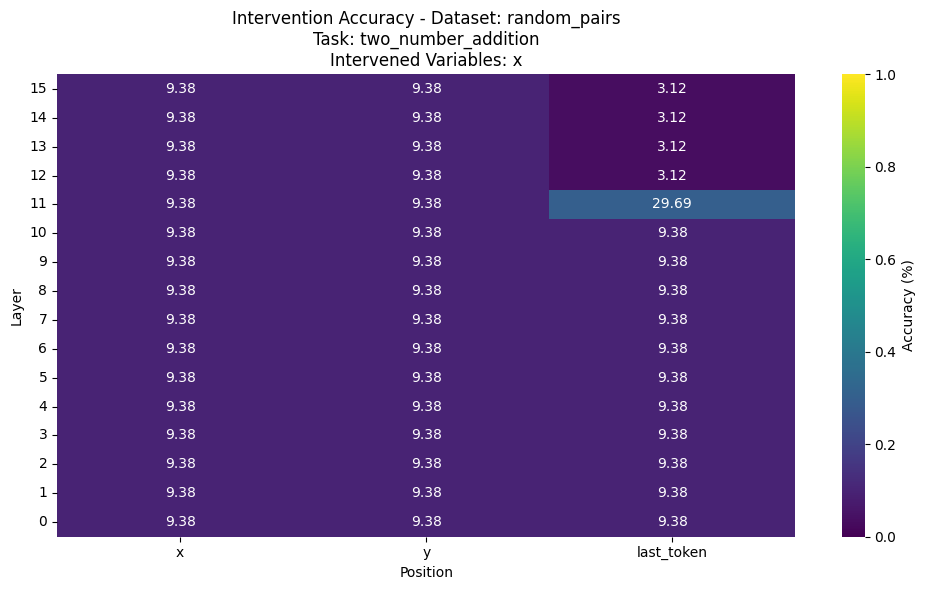

In [84]:
experiment.plot_heatmaps(raw_results, ["x"], save_path=results_dir)
# experiment.plot_heatmaps(raw_results, ["y"], save_path=results_dir)
# experiment.plot_heatmaps(raw_results, ["result"], save_path=results_dir)

In [ ]:
#############################
###   Switch to (x+y)+z   ###
#############################

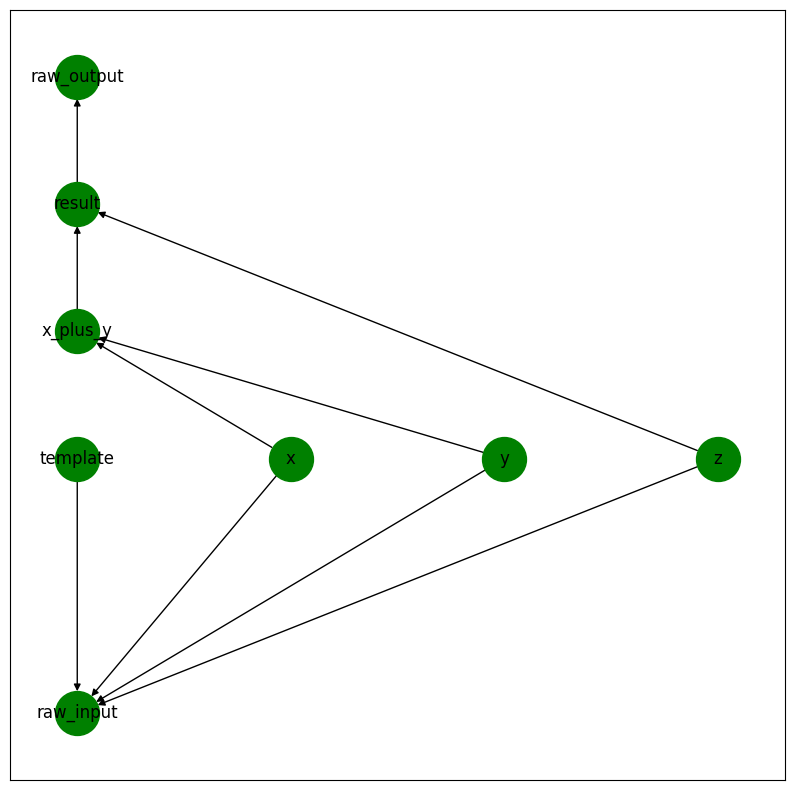

In [12]:
# Define a causal model
causal_model_triple = triple_add_task.causal_models["three_number_addition"]

causal_model_triple.print_structure()

In [13]:
# Generate an example
example = sample_triple_add_problem()
example

{'template': '<|endoftext|>, Yes, <x> + <y> + <z> = ',
 'x': 17,
 'y': 11,
 'z': 19,
 'raw_input': '<|endoftext|>, Yes, 17 + 11 + 19 = '}

In [14]:
# Run the causal model forward
full_setting = causal_model_triple.run_forward(example)
full_setting

defaultdict(None,
            {'template': '<|endoftext|>, Yes, <x> + <y> + <z> = ',
             'x': 17,
             'y': 11,
             'z': 19,
             'x_plus_y': 28,
             'result': 47,
             'raw_input': '<|endoftext|>, Yes, 17 + 11 + 19 = ',
             'raw_output': '47'})

In [15]:
# Manually intervene on x_plus_y and rerun
example["x_plus_y"] = 0
causal_model_triple.run_forward(example)

defaultdict(None,
            {'template': '<|endoftext|>, Yes, <x> + <y> + <z> = ',
             'x': 17,
             'y': 11,
             'z': 19,
             'x_plus_y': 0,
             'result': 19,
             'raw_input': '<|endoftext|>, Yes, 17 + 11 + 19 = ',
             'raw_output': '19'})

In [16]:
# Confirm interchange intervention works as expected
example = sample_triple_add_problem()
full_setting = causal_model_triple.run_forward(example)
new_example = sample_triple_add_problem()
new_full_setting = causal_model_triple.run_forward(new_example)

x0, y0, z0 = example["x"], example["y"], example["z"]
print(f"Original is {x0} + {y0} + {z0}  =  {x0+y0} + {z0}  =  {x0+y0+z0}")

x1, y1, z1 = new_example["x"], new_example["y"], new_example["z"]
print(f"New one  is {x1} + {y1} + {z1}  =  {x1+y1} + {z1}  =  {x1+y1+z1}")
print()
print(f"Intervention should be {x1+y1} + {z0}  =  {x1+y1+z0}")

intervened_full_setting = causal_model_triple.run_interchange(example, {"x_plus_y": new_example})
intervened_full_setting

Original is 18 + 17 + 6  =  35 + 6  =  41
New one  is 1 + 1 + 18  =  2 + 18  =  20

Intervention should be 2 + 6  =  8


defaultdict(None,
            {'template': '<|endoftext|>, Yes, <x> + <y> + <z> = ',
             'x': 18,
             'y': 17,
             'z': 6,
             'x_plus_y': 2,
             'result': 8,
             'raw_input': '<|endoftext|>, Yes, 18 + 17 + 6 = ',
             'raw_output': '8'})

Original:
Causal output is 9 + 14 + 18  =  23 + 18  =  41
Neural output is 41

Counterfactual:
Causal output is 9 + 18 + 11  =  27 + 11  =  38
Neural output is 38

Intervention should be 27 + 18  =  45

Running SameLengthResidualStreamTracing experiment...


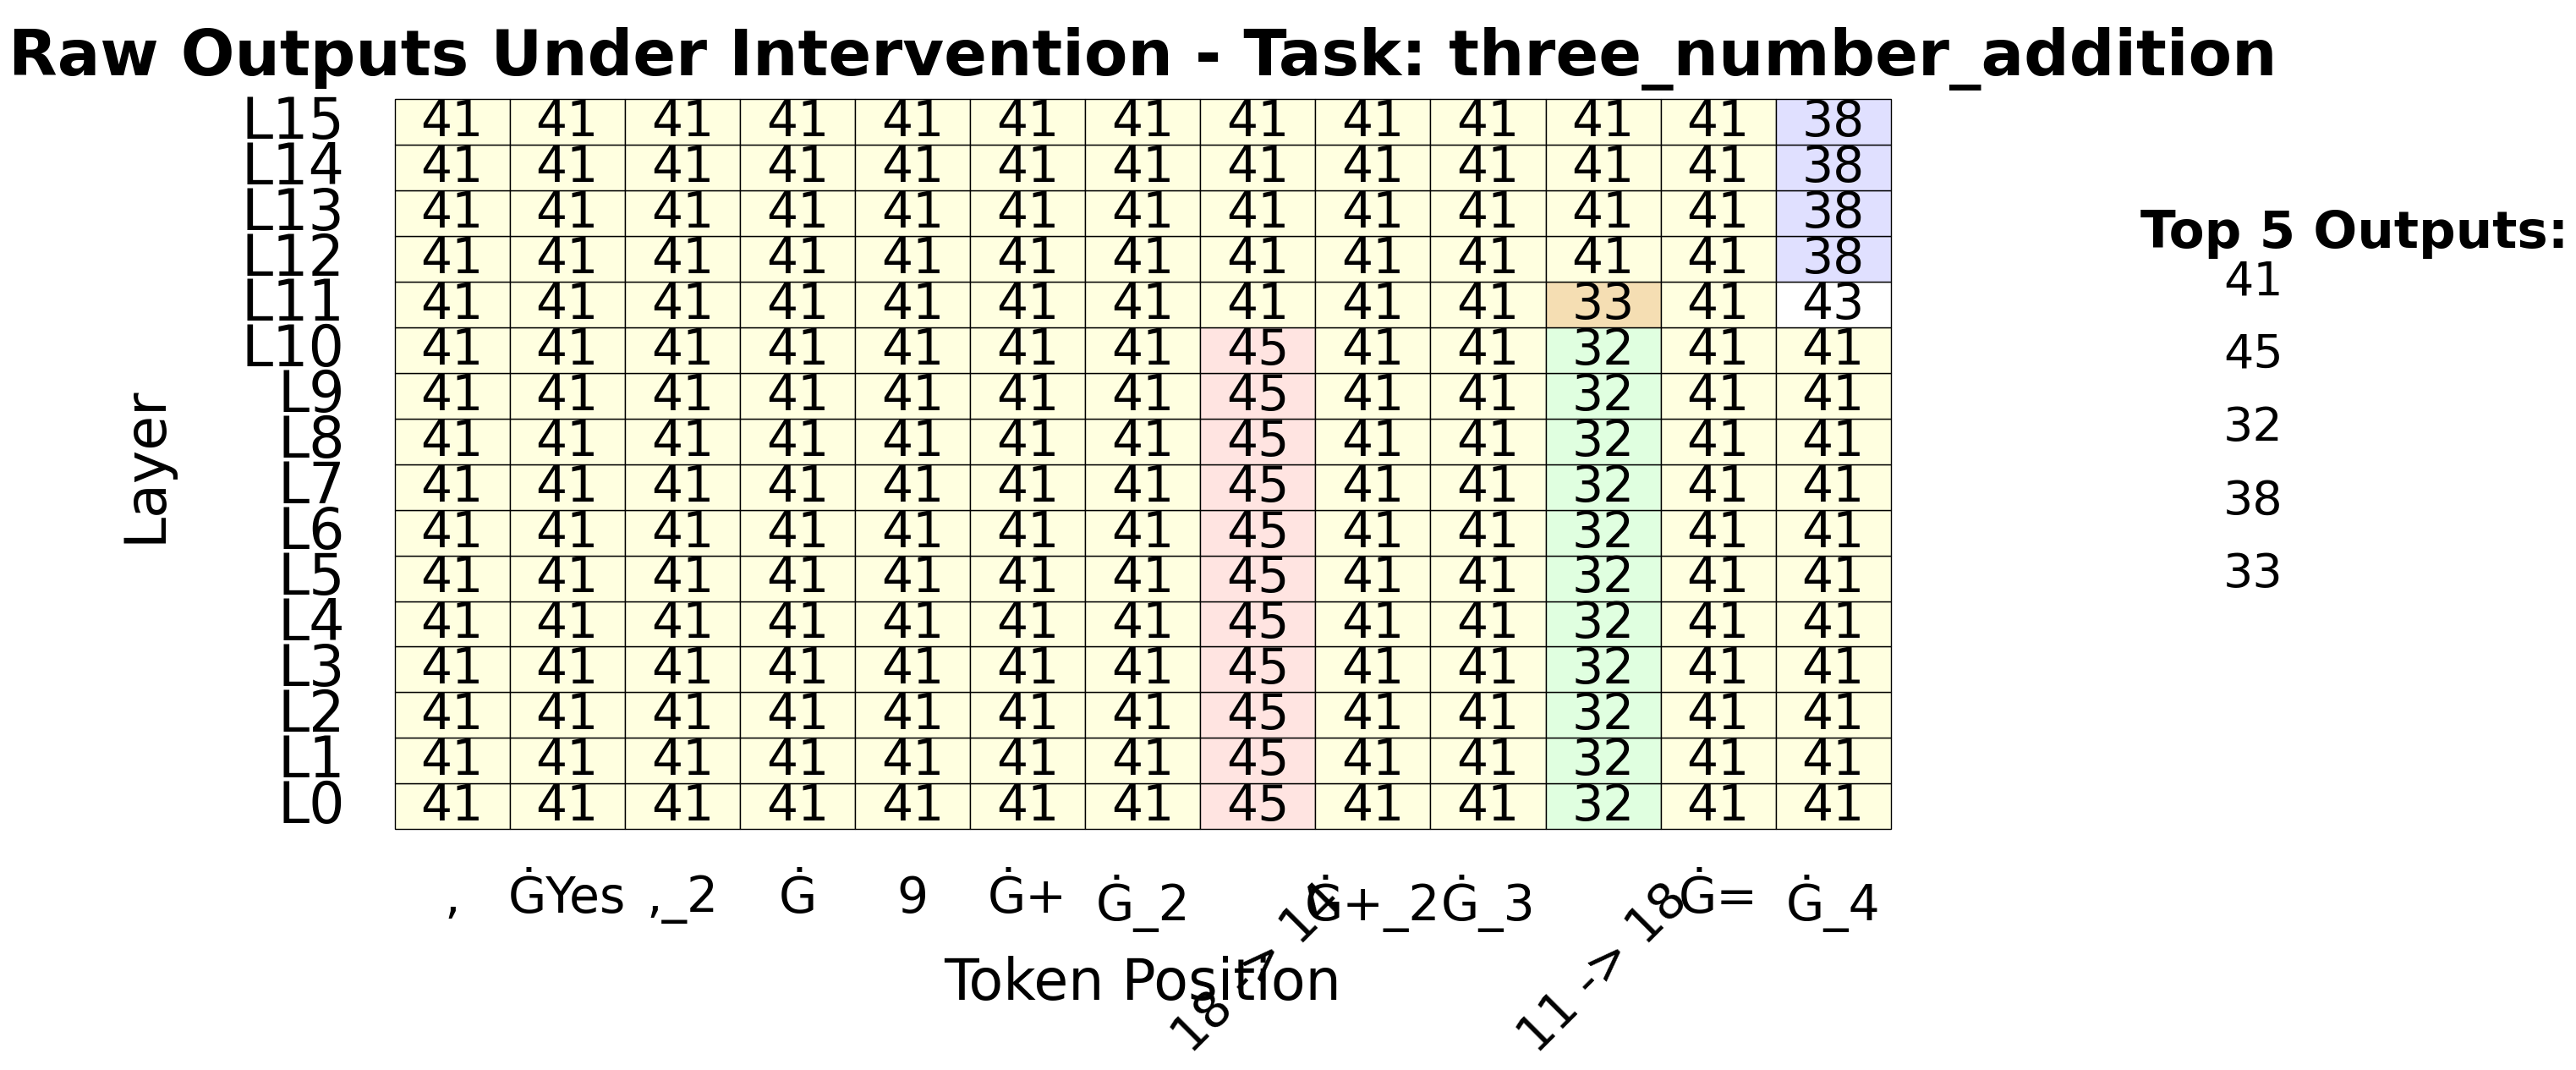


Tracing completed for 4 layer-position combinations


In [26]:
# Compare LM outputs for single pair intervention
# Takes about 35 seconds

# Import the tracing experiment
from experiments.LM_experiments.residual_stream_experiment import SameLengthResidualStreamTracing

original = sample_triple_add_problem()
counterfactual = sample_triple_add_problem()

x0, y0, z0 = original["x"], original["y"], original["z"]
neural_output = pipeline.generate(original["raw_input"])["string"]
print("Original:")
print(f"Causal output is {x0} + {y0} + {z0}  =  {x0+y0} + {z0}  =  {x0+y0+z0}")
print(f"Neural output is {neural_output}")

x1, y1, z1 = counterfactual["x"], counterfactual["y"], counterfactual["z"]
neural_output = pipeline.generate(counterfactual["raw_input"])["string"]
print("\nCounterfactual:")
print(f"Causal output is {x1} + {y1} + {z1}  =  {x1+y1} + {z1}  =  {x1+y1+z1}")
print(f"Neural output is {neural_output}")
print()
print(f"Intervention should be {x1+y1} + {z0}  =  {x1+y1+z0}")

# Run the tracing experiment
print("\n" + "="*50)
print("Running SameLengthResidualStreamTracing experiment...")
print("="*50)

# Create the tracing experiment
tracing_exp = SameLengthResidualStreamTracing(
    pipeline=pipeline,
    causal_model=causal_model_triple,
    checker=checker,
)

# Run the experiment with our counterfactual pair
results = tracing_exp.run(
    base_input=original,
    counterfactual_input=counterfactual
)

tracing_exp.plot_raw_outputs(results, "./tracing_results/tracing_heatmap.png")
print(f"\nTracing completed for {len(results)} layer-position combinations")

In [21]:
# Generates 64 random pairs (both are random, not just the counterfactual)
from causal.counterfactual_dataset import CounterfactualDataset
random_pairs = CounterfactualDataset.from_sampler(64, triple_add_task.dataset_generators["random_counterfactual"])

print(random_pairs[0])
print()
print("Original input:")
print(random_pairs[0]["input"]["raw_input"])
print("\nCounterfactual input:")
print(random_pairs[0]["counterfactual_inputs"][0]["raw_input"])
print("\nOriginal input:")
print(random_pairs[1]["input"]["raw_input"])
print("\nCounterfactual input:")
print(random_pairs[1]["counterfactual_inputs"][0]["raw_input"])

{'input': {'raw_input': '<|endoftext|>, Yes, 18 + 18 + 10 = ', 'template': '<|endoftext|>, Yes, <x> + <y> + <z> = ', 'x': 18, 'y': 18, 'z': 10}, 'counterfactual_inputs': [{'raw_input': '<|endoftext|>, Yes, 10 + 5 + 16 = ', 'template': '<|endoftext|>, Yes, <x> + <y> + <z> = ', 'x': 10, 'y': 5, 'z': 16}]}

Original input:
<|endoftext|>, Yes, 18 + 18 + 10 = 

Counterfactual input:
<|endoftext|>, Yes, 10 + 5 + 16 = 

Original input:
<|endoftext|>, Yes, 19 + 7 + 17 = 

Counterfactual input:
<|endoftext|>, Yes, 13 + 4 + 16 = 


In [22]:
# Check distinguishability of pairs of variables
causal_model_triple.can_distinguish_with_dataset(random_pairs, ["result"], None)
causal_model_triple.can_distinguish_with_dataset(random_pairs, ["x_plus_y"], None)
causal_model_triple.can_distinguish_with_dataset(random_pairs, ["result"], ["x_plus_y"])
pass

Can distinguish between ['result'] and None: 63 out of 64 examples
Proportion of distinguishable examples: 0.98
Can distinguish between ['x_plus_y'] and None: 62 out of 64 examples
Proportion of distinguishable examples: 0.97
Can distinguish between ['result'] and ['x_plus_y']: 61 out of 64 examples
Proportion of distinguishable examples: 0.95


In [28]:
# Compute interchange intervention accuracy
from experiments.LM_experiments.residual_stream_experiment import PatchResidualStream

token_positions = list(addition_task.create_token_positions(pipeline).values())

start = 0
end = pipeline.get_num_layers()
config = {"batch_size":64}
target_variables_list  = [["x_plus_y"]]
results_dir = "vector_patching_results"

experiment = PatchResidualStream(pipeline, causal_model_triple, list(range(start, end)), token_positions, checker, config=config)
raw_results = experiment.perform_interventions({'random_pairs': random_pairs}, verbose=True, target_variables_list=target_variables_list)

Running interventions:   0%|          | 0/48 [00:00<?, ?it/s, dataset=random_pairs, units=[[AtomicModelUnit(id='ResidualStream(Layer-0,Token-x)')]]]

Running interventions: 100%|██████████| 48/48 [00:12<00:00,  3.94it/s, dataset=random_pairs, units=[[AtomicModelUnit(id='ResidualStream(Layer-15,Token-last_token)')]]]


vector_patching_results/heatmap_dataset_random_pairs_task_three_number_addition_variables_x_plus_y.png


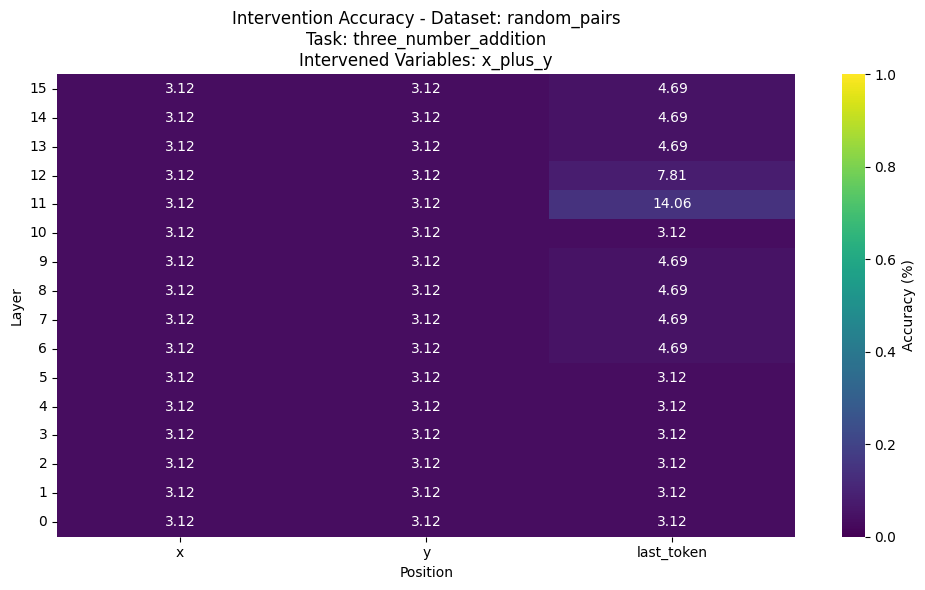

In [29]:
experiment.plot_heatmaps(raw_results, ["x_plus_y"], save_path=results_dir)